# Capstone 3: Data Wrangling & EDA

## Import Statements

In [11]:
import sys
import re
import os
sys.path.append('../../OCTCV/')
from octcv.arrViz import GridDimensionOptimizer,vizInputParser,volumeViewer
from octcv.mdl_lib import XVolSet,yX_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display_markdown,Markdown,Image,display
from imageio import mimsave

from skimage.metrics import structural_similarity as ssim
from scipy.ndimage import center_of_mass

---

## Data Wrangling

### Prior Data Wrangling

As this project is a continuation of Capstone 2, much of the data cleaning has already been done.  As a reminder, during Capstone 2, the orignal dataset of 1110 Optic Nerve Head (ONH) - centered OCT scans that had been downsampled to (64,128,64) and saved as `.npy` files were downloaded to `OCTCV/datasrc/volumesOCT/`, and various tabular features, such as the target/label/dx_class (glaucoma vs. normal), laterality, patient identification number were extracted from the filenames themselves into a dataframe.  During pre-processing, the dataset was further re-structured such that both original volumes and normalized versions were available as filepaths, and one-hot-encoding of categorical features were included.  This final dataset was saved to `OCTCV/p5_Modeling/volumes.csv` and will be the starting point of this project.

### Loading Dataset

In [12]:
df = pd.read_csv('../p5_Modeling/volumes.csv')
df.head(3)

,dx_class,glaucoma,PIN,laterality,left_eye,set,normalized_array,display_volume
0,normal,0,1,OD,0,1,../datasrc/volumesOCT/normalized/p001_Normal_O...,../datasrc/volumesOCT/Normal-000002-2009-10-28...
1,normal,0,1,OS,1,1,../datasrc/volumesOCT/normalized/p001_Normal_O...,../datasrc/volumesOCT/Normal-000002-2009-10-28...
2,glaucoma,1,2,OD,0,1,../datasrc/volumesOCT/normalized/p002_Glaucoma...,../datasrc/volumesOCT/POAG-000008-2009-02-03-O...


### Data Definition

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1110 entries, 0 to 1109
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   dx_class          1110 non-null   object
 1   glaucoma          1110 non-null   int64 
 2   PIN               1110 non-null   int64 
 3   laterality        1110 non-null   object
 4   left_eye          1110 non-null   int64 
 5   set               1110 non-null   int64 
 6   normalized_array  1110 non-null   object
 7   display_volume    1110 non-null   object
dtypes: int64(4), object(4)
memory usage: 69.5+ KB


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
glaucoma,1110.0,0.763063,0.425395,0.0,1.0,1.0,1.0,1.0
PIN,1110.0,311.331532,181.711099,1.0,154.0,311.5,468.0,624.0
left_eye,1110.0,0.496396,0.500212,0.0,0.0,0.0,1.0,1.0
set,1110.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0


#### Additional Data Info

During Capstone 2, the custom method `octcv.yX_split` was used to split the target labels (y) from the associated volume filepaths and also instantiate them as an instance of a custom `XVolSet` class which allows for lazy-/on-the-fly loading of the actual (64,128,64) NumPy arrays (e.g., via `X.load()` to load the whole set of 1110 volumes, or with indexing, such as `X[0:3].load()` to load the first three volumes only) in order to save on memory.

For this project, some updates were made to the `XVolSet` class, including a new `describe` method, similar to that of pandas DataFrames along with their `info()` method, providing some summary information regarding the dataset: 

In [15]:
# loading the normalized volumes
yl,y,X = yX_split(df,default_load_normalized=True)
X.describe()

,min,max,mean,std,shape,dtype,ndim,n_items,size,nbytes
value,0.0,0.898039,0.14122,0.095732,"(1110, 64, 128, 64, 1)",float64,5,"581,959,680",4.66 GB,4655677440


In [16]:
# Loading the original volumes / re-assigning variables
yl,y,X = yX_split(df,default_load_normalized=False)
X.describe()

,min,max,mean,std,shape,dtype,ndim,n_items,size,nbytes
value,0,229,36.011068,24.411613,"(1110, 64, 128, 64, 1)",uint8,5,"581,959,680",581.96 MB,581959680


Note that the `size` column represents the size of the dataset once all the volumes are loaded.

As the normalized arrays are of `dtype = float64`, the total size of the dataset is significantly larger than the original arrays with values within typical pixel ranges (0,255), as the `dtype = uint8`.  Due to both smaller size and relevance (i.e., normalized volumes were created for the purpose of modeling, not EDA), we will be using the non-normalize/original volumes; as the pixel values fall within the 0-255 range, this should be more appropriate for data visualization steps.

---

## Exploratory Data Analysis (EDA)

As described in the Project Proposal, the objective includes data augmentation during the pre-training step, which involves the application of various transformations that simulate commonly found artifacts/noise commonly found in such visual data.  In doing so, the hope is that the CNN model will learn to classify glaucoma vs. normal regardless of whether such "impurities" are present, leading to more robust model performance overall.  For OCT scans, this may include:

+ **Monochromatic Lens Abberations** - Geometric / Jitter Transformations
+ **Signal Strength Variations** - Global Brightness/Contrast Adjustments
+ **Speckle Noise due to Wave Interference** - Ralyeigh-Distributed Noise Injection

To inform the specifics of the augmentation approach, EDA will be performed to account for

1. General variations within and between the target classes (Glaucoma vs. Normal)
2. More specific differences between said classes within each of the image characteristics that may be altered with the aforementioned transformations for data augmentation.

### General Intra-Class Structural Variations

#### Prior EDA: Class Imbalance

As noted during EDA of Capstone 2, there was a notable imbalance between the target classes:

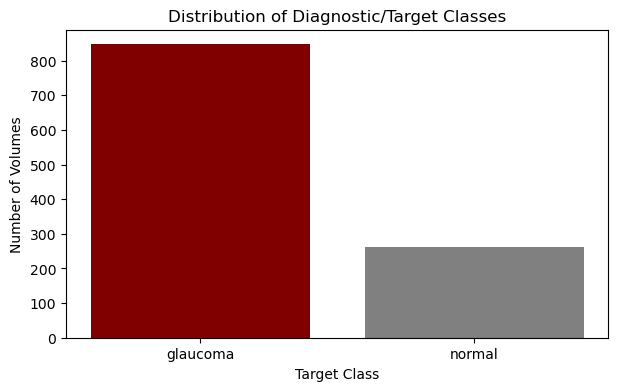

In [17]:
targets, target_counts = np.unique(yl,return_counts=True)
plt.figure(figsize=(7,4))
_ = plt.bar(targets,
            target_counts,
            color=['maroon','gray'])
plt.xlabel('Target Class')
plt.ylabel('Number of Volumes')
_ = plt.title('Distribution of Diagnostic/Target Classes')

However, considering the original authors of the dataset had trained with the same dataset and achieved good perfomance in spite of this class imbalance, the models in Capstone 2 were trained on both this original dataset and a balanced version in which the glaucoma class was downsampled to match the size of the normal class.  While the better overall performance of the models with the original, unbalanced, dataset could have been attributed to there simply being a larger sample size overall, it was hypothesized that perhaps there was more variation in the retinal anatomy of glaucoma compared to that of normal, healthy eyes, thus requiring more examples of how glaucoma may appear on ONH-centered OCT scans for the model to learn and generalize the visual features of glaucoma as disctinct from that of normal.

#### Structural Similarity

To evaluate the hypothesis of the glaucoma class having more structural variation than the normal one, we do a slice-wise, interpretable variation to a raw calculation of structural similarity index measure (SSIM) between random volumes:

In [18]:
# Function for calculating slice-by-slice SSIM scores comparing a given volume to a mean reference volume 
def volume_ssim_to_mean(vol, mean_vol):
    scores = []
    for z in range(vol.shape[2]):
        score = ssim(
            vol[:,:,z],
            mean_vol[:,:,z],
            data_range=mean_vol[:,:,z].ptp()
        )
        scores.append(score)
    return np.mean(scores)

In [19]:
# Extract indices corresponding to each target class
gs = np.where(df['dx_class'] == 'glaucoma')[0]
print(gs.shape)
ns = np.where(df['dx_class'] == 'normal')[0]
print(ns.shape)

(847,)
(263,)


In [20]:
# Average all volumes within each class
mean_glaucoma = X.load()[gs].mean(axis=0).reshape(64,128,64)
mean_normal = X.load()[ns].mean(axis=0).reshape(64,128,64)

In [21]:
# Calculate slice-wise SSIM scores of all volumes within classes with respect to their average volumes 
g_scores = [volume_ssim_to_mean(v.reshape(64,128,64), mean_glaucoma) for v in X[gs].load()]
n_scores = [volume_ssim_to_mean(v.reshape(64,128,64), mean_normal) for v in X[ns].load()]

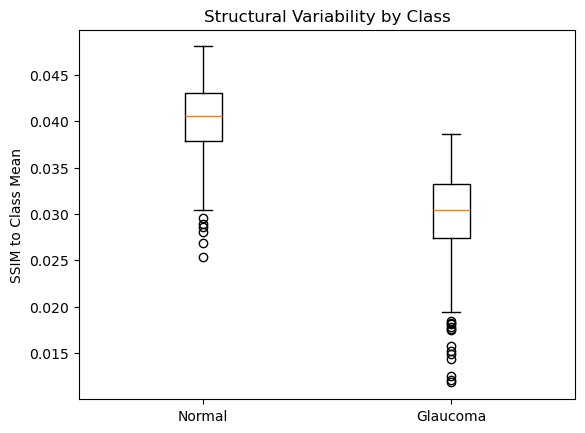

<Figure size 640x480 with 0 Axes>

In [22]:
# Plot comparison between score distributions of the two classes
plt.boxplot([n_scores, g_scores], tick_labels=["Normal", "Glaucoma"])
plt.ylabel("SSIM to Class Mean")
plt.title("Structural Variability by Class")
plt.show()
_ = plt.savefig('ssim_boxplot.png',bbox_inches='tight',transparent=False)

The box plots serve as global indicators of intra-class variance. Because the SSIM index is a composite metric -- incorporating comparisons of luminance ($\mu$), contrast ($\sigma$), and structural patterns ($c$) -- the lower scores and increased spread in the Glaucoma class signify a higher total "feature volatility" compared to the Normal class. This validates the hypothesis made at the end of Capstone 2 that a larger proportion of Glaucoma samples is required to adequately map its more complex and heterogeneous manifold.

From an augmentation perspective, this suggests that while we must simulate imaging artifacts (noise and lens distortions), we must do so with a "light touch". If the augmentations introduce variance that exceeds the natural structural/radiometric spread shown here, we risk over-homogenizing the dataset and diluting the subtle pathological signals.  Consequently, the specific parameters for the Rayleigh noise and brightness adjustments will be tuned to stay within the 'natural' bounds identified in the subsequent spectral and intensity analyses, ensuring that the simulated noise does not drown out the underlying anatomical heterogeneity.

### EDA for Specific Augmentation Approachs

#### Geometric / Lens Distortion EDA

The objective here is to measure how retinal layers / structure positions vary across volumes, which informs on safe bounds for jitter.

##### Center-of-mass variation along axes

By calculating the Center of Mass (COM) for each volume, which represents the intensity-weighted "centroid" or balance point of the 3D signal, we can quantify how consistently the retinal structures are centered across the dataset. Analyzing the mean and standard deviation of these centroids across the depth, height, and width axes reveals the typical positional "drift" or offset present in the raw scans. These metrics provide a data-driven baseline for setting jitter and translation limits during augmentation; if the natural positional variance is very low, our synthetic shifts must remain similarly constrained to avoid creating unrealistic anatomical placements that the model wouldn't encounter in a clinical setting.

In [23]:
def compute_volume_com_stats(X, y, axis=(1,2,3)):
    """
    Computes mean and std of center-of-mass per volume along each spatial axis
    X: your custom dataset class
    y: labels
    axis: axes over which to compute COM (ignore batch and channel)
    """
    X_data = X.load()  # shape (N,64,128,64,1)
    X_data = X_data[...,0]  # drop channel axis for simplicity
    N = X_data.shape[0]

    coms = np.zeros((N, 3))  # z,y,x
    for i in range(N):
        coms[i] = center_of_mass(X_data[i])

    com_stats = {}
    for cls in [0,1]:
        cls_idx = np.where(y[:,0]==cls)[0]
        cls_com = coms[cls_idx]
        com_stats[cls] = {
            'mean': cls_com.mean(axis=0),
            'std': cls_com.std(axis=0)
        }
    return com_stats

com_stats = compute_volume_com_stats(X, y)
com_statsf = { i:{m:tuple(coords.round(2)) for m,coords in stat.items()} for i,stat in com_stats.items() }
display(pd.DataFrame(com_statsf))

,0,1
mean,"(31.66, 59.24, 31.45)","(31.57, 58.84, 31.49)"
std,"(0.31, 3.41, 0.3)","(0.31, 3.3, 0.33)"


The Center of Mass (COM) analysis demonstrates high spatial stability and consistency across both classes. With mean coordinates differing by less than 0.4 pixels across all three axes (specifically $x \approx 31.6$, $y \approx 59.0$, and $z \approx 31.5$) the two cohorts are effectively co-registered within the volume space. The remarkably low standard deviations (particularly in the $x$ and $z$ planes at $\sigma \approx 0.3$) indicate that the volumes do not suffer from significant "drift" or positioning artifacts.

This spatial uniformity is critical for the validity of subsequent structural analyses; it confirms that the lower SSIM scores observed in the Glaucoma class are a result of internal anatomical heterogeneity and pathological remodeling rather than global misalignments or cropping inconsistencies. 

Consequently, for the augmentation pipeline, this suggests that random translations should be kept to a minimum. Since the base dataset is already highly localized, keeping the anatomy centered allows the 3D CNN to focus its kernels on consistent spatial regions where the pathological signal (the thinning seen in the max projection profiles) is known to occur.

##### Spatial Intensity Distribution & Structural Mapping

To isolate the most significant anatomical features from the 3D OCT volumes, we use a Max Intensity Projection (MIP). This function "compresses" the 3D data along a given axis (default axis=1) by extracting only the maximum pixel value encountered along each vertical ray. By reducing each volume to a 1D "structural signature," we can efficiently compare the peak reflectivity profiles of the retina across the entire dataset without the noise of less-reflective secondary structures. These peak reflective profiles serve as a rough proxy for the main reflective layers in OCT, such as the Internal Limiting Membrane (ILM) or Retinal Pigment Epithelium (RPE).

In [24]:
def compute_max_projection_profiles(X, axis=1):
    """
    Computes max intensity projection along a given axis.
    Returns per-volume 1D profiles to visualize structural variation.
    """
    X_data = X.load()[...,0]
    profiles = np.max(X_data, axis=axis)  # max projection
    return profiles

Using the function, a plot can be produced which maps the 1D signatures of every scan in the dataset to reveal the Spatial Intensity Distribution by class. 

By overlaying a high-transparency "fuzz" of individual volume scan profiles behind the class means, we aim to determine if the structural thinning associated with glaucoma is spatially consistent across the cohort. 

This allows us to verify two critical assumptions that inform the approach to augmentation: 

1. Whether the "diagnostic signal" is localized to specific coordinates (justifying tight jitter/translation limits)
2. Whether the Glaucoma class exhibits greater natural spread in intensity than the Normal class, which would confirm the heterogeneity observed in the previous SSIM analysis.

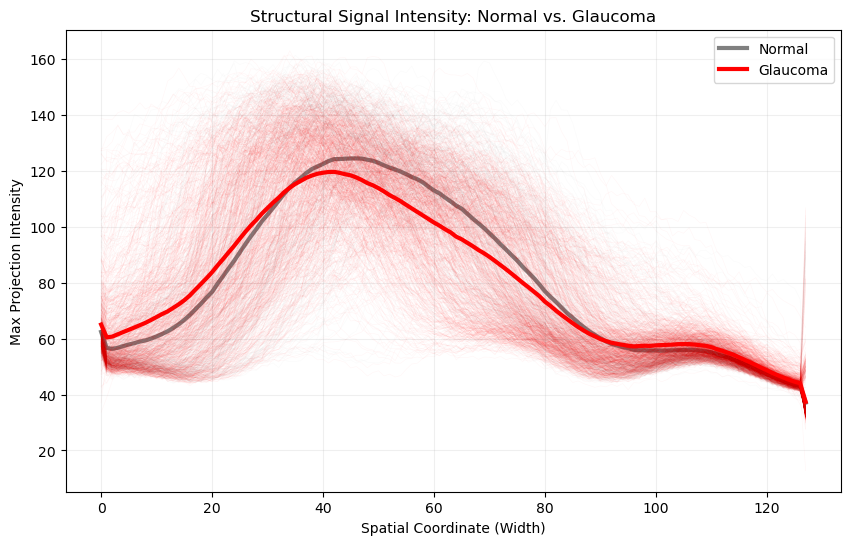

In [25]:
profiles = compute_max_projection_profiles(X, axis=1)  # height axis

# Ensure profiles is exactly (N, Width)
if profiles.ndim == 3:
    # If shape is (N, Width, Something), average out the 'Something'
    profiles_2d = profiles.mean(axis=2) 
else:
    profiles_2d = profiles

plt.figure(figsize=(10,6))
class_map = {0: ("Normal", "gray"), 1: ("Glaucoma", "red")}

for cls, (label, color) in class_map.items():
    # Get indices for this class
    idxs = np.where(y[:, 0] == cls)[0]
    cls_data = profiles_2d[idxs] # Shape: (samples_in_class, 128)
    
    # Plot the background 'fuzz'
    # Note: using the transpose so matplotlib sees it as 'N' separate lines
    plt.plot(cls_data.T, c=color, alpha=0.03, linewidth=0.5, label='_nolegend_')
    
    # Plot the MEAN profile with a bold line
    plt.plot(cls_data.mean(axis=0), c=color, linewidth=3, label=label)

plt.legend()
plt.title("Structural Signal Intensity: Normal vs. Glaucoma")
plt.xlabel("Spatial Coordinate (Width)")
plt.ylabel("Max Projection Intensity")
plt.grid(alpha=0.2)
_ = plt.savefig('max-projection-profiles_plot.png',bbox_inches='tight',transparent=False)

The mean max projection profiles reveal a localized divergence in signal intensity between the two classes. Specifically, the "Normal" class (gray) exhibits higher peak intensities between $x=35$ and $x=80$ compared to the "Glaucoma" class (red), which is a quantitative signature of pathological thinning in the neuroretinal tissue. Conversely, the areas where the "Normal" profiles dip below the "Glaucoma" profiles ($x=0$ to $x=30$) likely represent peripheral zones where healthy anatomy is more uniform, while glaucomatous eyes may exhibit irregular cupping or structural remodeling.

Building on the objective to define a realistic "geometric budget" for transformations, the Max Projection Profiles demonstrate that the primary diagnostic signal is spatially localized. While the SSIM analysis confirms a high degree of class-wise heterogeneity, these profiles show that this variance is not stochastic but fundamentally tied to anatomical landmarks.

Consequently, the augmentation strategy must preserve these spatial relationships; excessive warping, rotation, or shearing could displace these diagnostic "peaks" and "troughs" out of their natural anatomical context. By limiting geometric transformations to a range that maintains the relative orientation of these profiles, we ensure the 3D CNN learns to associate specific regional thinning with glaucoma rather than treating these critical features as translation-invariant artifacts.

#### Brightness / Contrast EDA

##### Pixel Intensity Summary Stats 

In [26]:
def intensity_stats(X, y):
    X_data = X.load()[...,0]
    stats = {}
    for cls in [0,1]:
        idxs = np.where(y[:,0]==cls)[0]
        cls_data = X_data[idxs].ravel()
        stats[cls] = {
            'mean': cls_data.mean(),
            'std': cls_data.std(),
            'min': cls_data.min(),
            'max': cls_data.max()
        }
    return stats

stats = intensity_stats(X, y)
display(pd.DataFrame(stats).T)

,mean,std,min,max
0,37.006702,25.757517,0.0,229.0
1,35.701916,23.969922,0.0,222.0


The global intensity statistics reveal that both classes occupy nearly identical dynamic ranges ($0$ to $\approx 225$) with remarkably similar mean intensities ($\approx 36$ to $37$). The fact that the "Normal" class exhibits a slightly higher mean and standard deviation $(\sigma \approx 25.7$ vs $23.9)$ aligns with the structural findings: healthy retinal tissue typically possesses more high-reflectivity voxels than glaucomatous tissue.

For the augmentation strategy, these statistics confirm that global brightness and contrast adjustments should be applied symmetrically to both classes. Because the base signal is relatively "dark" (means near $15\%$ of the $0-255$ range) and the variance is consistent, we can safely simulate varying OCT signal strengths by shifting these means without risking "clipping" or unnatural saturation. Furthermore, because the intensity profiles are so similar at a global level, this reinforces the idea that the model must rely on spatial patterns (as seen in the Max Projection profiles) rather than simple pixel-value thresholds to distinguish between the two classes.

##### Pixel Intensity Percentile ranges

In [27]:
def intensity_percentiles(X, y, percentiles=[1,5,25,50,75,95,99]):
    X_data = X.load()[...,0]
    perc = {}
    for cls in [0,1]:
        idxs = np.where(y[:,0]==cls)[0]
        cls_data = X_data[idxs].ravel()
        perc[cls] = np.percentile(cls_data, percentiles)
    return perc

perc = intensity_percentiles(X, y)
display(pd.DataFrame(perc,index=[1,5,25,50,75,95,99]).T)

,1,5,25,50,75,95,99
0,4.0,11.0,21.0,29.0,43.0,96.0,128.0
1,3.0,11.0,21.0,29.0,42.0,89.0,122.0


The percentile data confirms a heavily right-skewed distribution where the diagnostic signal (high-reflectivity layers) resides almost exclusively in the top 5% of intensities. The divergence at the 99th percentile ($128$ for Normal vs. $122$ for Glaucoma) quantifies the reflectivity loss in pathological tissue.

This informs a shift in the augmentation strategy: rather than using simple linear brightness shifts, it may be better to utilize **Gamma correction** or **CLAHE (Contrast Limited Adaptive Histogram Equalization)**. These techniques are more "realistic" for OCT as they selectively enhance the contrast within the narrow high-intensity band (the retinal layers) without disproportionately inflating the lower-intensity background noise floor (1st to 75th percentiles).

#### Signal-Noise EDA

##### Frequency-Domain Analysis Background

A **Fourier Transform (FT)** decomposes a complex signal into a sum of sinusoids with varying frequencies. In the context of OCT volumes, the complex signal encoded in a given volume can be viewed as a 3D pixel intensity function $I(x,y,z)$, and the spatial frequencies resulting from the FT represents the local rates of change in voxel intensity; low frequencies capture the general global anatomy, while high frequencies capture fine details, sharp boundaries, and stochastic noise.

> NOTE: while the FT is often presented as a decomposition of a *continous* function/signal, it can also be done for *discrete* signals, like the volumes in this project.  This type of FT, called a **Discrete Fourier Transform (DFT)**, is commonly used in computational contexts such as this one.  The standard algorithm that is highly optimized for calculating a DFT is the **Fast Fourier Transform (FFT)**, which is implemented in the `numpy.fft` module.

However, interpreting a FT directly can sometimes be difficult due to the presence of complex-valued components containing both magnitude and phase information.  As a result, it is common to visualize the energy distribution across these frequencies by calculating the Power Spectrum (PS), which is the squared magnitude of the Fast Fourier Transform (FFT):

$$\text{PS} = |\text{FFT}(I(x,y,z))|^2$$

The zero-frequency component, often called the DC (Direct Current) component, represents the global average intensity of the entire volume. By default, the FFT algorithm places this component at the origin (the corner) of the output array. However, this component can be moved to the center of the spectrum using `numpy.fft.fftshift`, which visually aligns the data so that low-frequency structural energy is at the "core" and high-frequency noise is at the "periphery".

---

All of the above is incorporated into the following function:

In [28]:
def volume_power_spectrum(vol):
    # 3D FFT
    fft = np.fft.fftn(vol) # fftn refers to fft for n-dimensional signals, where n > 2
    power = np.abs(fft) ** 2
    return np.fft.fftshift(power)

To simplify the 3D Power Spectrum into an interpretable 1D visualization, one can calculate a Radial Mean Profile.  This process involves measuring the Euclidean distance of every frequency component from the centered DC component. By averaging all energy values at a given radius $r$, volumetric data is collapsed into a single curve.

In [29]:
def radial_profile_3d(power):
    z, y, x = np.indices(power.shape)
    center = np.array(power.shape) // 2
    r = np.sqrt((x-center[2])**2 + (y-center[1])**2 + (z-center[0])**2)
    r = r.astype(int)

    radial_mean = np.bincount(r.ravel(), power.ravel()) / np.bincount(r.ravel())
    return radial_mean

##### Visualizing Individual Volume Example, its Power Spectra, and Radial Profile

<div class="alert alert-warning alert-dismissible fade show" style="color:black">
    <strong>Note:</strong> <i> &nbsp; Some of the following code cells involve usage of the <code>sliceViewer</code> method of a new <code>octcv.arrViz.volumeViwer</code> class (instantiated as <code>vv</code>) in the custom library for the project.  As this is built upon <code>plotly</code> and may not render in GitHub previews, such code is commented out for now.
<br><br>
If viewing in an active jupyter notebook, one can uncomment them and adjust the slider bar to view the different frames of the volume along axis 1 as desired.  
<br><br>
Otherwise, the GIF display comparing the original OCT scan and its power spectrum as slices along axis 1 should give one a general idea.</i>
<br>
</div>

###### Single Volume - Original OCT Scan

In [30]:
vol = X[20].load()[0,...,0]

# vv = volumeViewer()
# vv.sliceViewer(vol,axis=1)

###### Single Volume - Power Spectra

In [31]:
vps = volume_power_spectrum(vol)

# vv.sliceViewer(vps,axis=1)

In [32]:
vps.min(),vps.max()

(804.7794182106638, 372113860804009.0)

As the power spectra has such a broad dynamic range of values, it may be helpful to take the logarithm of it and rescaling to 0-255 for easier visualization:

In [33]:
logvps = np.log10(vps)
logvps *= 255 // logvps.max()
logvps = logvps.astype(np.float64)

# vv.sliceViewer(logvps,1)

###### Single OCT Scan & Power Spectra Comparison GIF

In [34]:
combined_frames = []
for i in range(vol.shape[1]):   
    side_by_side = np.hstack((vol[:,i,:], logvps[:,i,:]))
    combined_frames.append(side_by_side)

mimsave('vol-vps_ax-1_comparison.gif', 
                combined_frames, 
                fps=20, loop=0)

<table style="width: 40%; border: none; border-collapse: collapse; margin: 0; padding: 0; text-align: center; table-layout: fixed;">
  <tr>
    <td style="width: 50%; font-weight: bold; padding-bottom: 5px;"><u>Original OCT Volume</u></td>
    <td style="width: 50%; font-weight: bold; padding-bottom: 5px;"><u>Volume Power Spectrum</u></td>
  </tr>
  <tr>
    <td colspan="2" style="padding: 0;">
      <img src="vol-vps_ax-1_comparison.gif" style="width: 100%; display: block;">
    </td>
  </tr>
</table>


###### Radial Profile

Text(0, 0.5, 'Power')

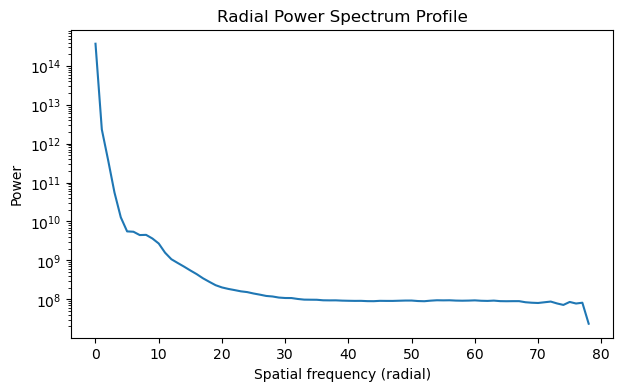

In [35]:
rp3D = radial_profile_3d(vps)
plt.figure(figsize=(7,4))
plt.plot(rp3D)
plt.yscale('log')
plt.title('Radial Power Spectrum Profile')
plt.xlabel("Spatial frequency (radial)")
plt.ylabel("Power")

In this plot, the distance from the center ($x$-axis) represents increasingly higher spatial frequencies, while the magnitude ($y$-axis) indicates the prevalence of those frequencies within the volume. This profile is essential for distinguishing between structural signal (which dominates the low-frequency peaks near the center) and stochastic noise (the "high-frequency tail" at the periphery).

##### Class-Wise Averages of Power Spectra in Radial Summary Plot

The radial power spectrum of every volume will be calculated and averaged for each class, and the resulting two class-averaged plots will be compared in a single plot to visualize any average differences in noise and signal of Glaucoma vs. Normal volumes.  

In [36]:
# Compute class-wise averages
glaucoma_profiles = []
normal_profiles = []

for i,(vol, label) in enumerate(zip(X, y)):  # X: (N,64,128,64)
    print(f"Computing for volume {i+1} of {len(y)}",end='\r')
    ps = volume_power_spectrum(vol.load())
    rp = radial_profile_3d(ps.reshape(64,128,64))
    if label == 1:
        glaucoma_profiles.append(rp)
    else:
        normal_profiles.append(rp)

print(f"Done - Radial Profiles Computed for {i+1}/{len(y)} Volumes",end='\r')

g_mean = np.mean(glaucoma_profiles, axis=0)
n_mean = np.mean(normal_profiles, axis=0)

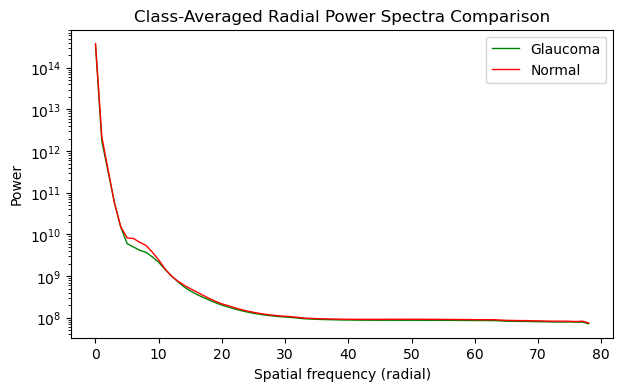

In [37]:
plt.figure(figsize=(7,4))
plt.plot(g_mean, label="Glaucoma", color='green',lw=1)
plt.plot(n_mean, label="Normal", color='red',lw=1)
plt.yscale("log")
plt.xlabel("Spatial frequency (radial)")
plt.ylabel("Power")
plt.legend()
plt.title("Class-Averaged Radial Power Spectra Comparison")
plt.savefig('radial-ps_class-comparison.png',bbox_inches='tight',transparent=False)

**Interpretation**

+ There is little seperation at higher frequncies ( > 20 ), suggesting no significant noise / sharpness differences between the classes.
+ The small but notable separation at low frequencies (5-20) likely represent true anatomical differences between the classes.

**Implications for Augmentation**

Because the baseline noise is balanced, noise injection should be applied symmetrically across both classes. To maintain physical realism, we will utilize a Rayleigh distribution to sample the synthetic noise from during augmentation. Unlike Gaussian noise, the Rayleigh distribution accurately characterizes the "speckle" caused by the constructive and destructive interference of light waves involved in OCT imaging.

Furthermore, this graph establishes limits to how strong the noise should be: the injected noise power must not elevate the high-frequency "tail" to a level that eclipses the low-frequency structural peaks. This ensures that the augmentation serves as a regularizer for the model's robustness rather than a mask that destroys the diagnostic signal.

Finally, the consistency of the high-frequency noise provides a baseline for **simulated denoising** via *low-pass filtering*, allowing us to augment the dataset with "cleaner" synthetic versions of the scans to improve the model's feature extraction at various signal-to-noise ratios (SNR).

## Summary & Conclusions 

#### 1. Data Wrangling
+ This project continues the trajectory of previous work, utilizing a cleaned dataset of 1,110 OCT volumes. As such, no additional cleaning steps were necessary.
+ As with Capstone 2: to manage the high memory overhead of volumetric data, the pipeline was architected to include Storage-Efficient Loading: Dataframes maintain filepaths and labels rather than raw voxels, ensuring a lightweight footprint for initial processing.
+ Using new custom data definition methods, we verified volume dimensions and estimated the total dataset size, which may be useful for calculating the computational budget and memory requirements for the subsequent 3D CNN training.

#### 2. Exploratory Data Analysis (EDA): Defining the Augmentation Budget
By analyzing the structural, spatial, and spectral properties of the scans, a "budget"  was established for how much the data can be transformed without losing the diagnostic signal.

+ **Structural Heterogeneity (SSIM Analysis):** Using Structural Similarity Indexing, we confirmed that Glaucoma volumes exhibit significantly higher internal variance than Normal scans. This justifies asymmetric sampling and reinforces the need for augmentation to help the model generalize across the "messier" glaucomatous manifold.

**Geometric/Lens Distortion EDA**
    
+ **Global Alignment (Center of Mass):** Our COM analysis proved that the anatomical features are well-centered across both classes. This high degree of registration justifies a conservative geometric augmentation strategy, where large-scale translations are avoided to maintain the spatial priors the model will learn.
+ **Spatial Intensity Profiles (Max Projection):** By squashing volumes into 1D reflectivity envelopes, we identified the ILM and RPE layers as the primary signal carriers. The observed thinning in Glaucoma cases informs our use of Gamma Correction and CLAHE to enhance high-reflectivity contrast without drowning the signal in background noise.

**Brightness/Contrast EDA**
    
+ **Pixel Intensity Summary Stats & Percentiles:** We discovered that the diagnostic signal is concentrated in the top 5% of intensities. This discovery steered us away from linear brightness shifts, which would wash out the data, toward more non-linear, realistic radiometric augmentations.

**Signal-Noise EDA**

+ **Spectral Integrity (Radial Power Spectra):** Through Fourier analysis, we mapped the "noise floor" of the OCT hardware. We found that stochastic noise is consistent across classes, justifying the symmetric injection of Rayleigh-distributed speckle noise. This ensures our model becomes invariant to wave-interference artifacts while remaining sensitive to the low-frequency structural differences that define the disease.

#### Conclusion: The Strategic Path Forward
The EDA confirms that while the cohorts are well-aligned globally, the "Glaucoma" signal is a subtle reduction in high-intensity structural energy. Consequently, our training phase will prioritize physics-informed augmentations—Rayleigh noise, Gamma correction, and minor rotations—ensuring the 3D CNN learns to distinguish pathology from hardware artifacts with high precision.

#### Potential Future Explorations
+ Training [Siamese Neural Networks (SNNs)](https://www.geeksforgeeks.org/nlp/siamese-neural-network-in-deep-learning/) to detect differences in different populations of volumes (i.e., the two classes).
+ PCA of embeddings from pre-trained CNNs 